# *EXTRACCIÓN o RECOLECCIÓN*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,0,No,No,4,Si,No,Fibra óptica,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Si,Masculino,1,Si,No,13,Si,No,Fibra óptica,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,1,Si,No,3,Si,No,Fibra óptica,...,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.9,267.40,2.796667


In [3]:
#Veo todas las columnas en formato de lista
df.columns

Index(['id', 'Churn', 'genero', 'tiene +60', 'posee_pareja',
       'posee_dependientes', 'tiempo_contrato', 'servicio_telefono',
       'multiples_lineas', 'tipo_internet', 'seguridad_online',
       'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'factura_digital', 'metodo_pago', 'valor_mensual', 'total_cobrado',
       'cuentas_diarias'],
      dtype='object')

In [4]:
#Para ver la informacion de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   tiene +60               7032 non-null   int64  
 4   posee_pareja            7032 non-null   object 
 5   posee_dependientes      7032 non-null   object 
 6   tiempo_contrato         7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

# *PREPROCESAMIENTO*

### ✅ Remover columnas irrelevantes

Al trabajar con modelos predictivos debo diferenciar cuáles son las variables que van a influir en el modelo, de las que son relevantes

In [5]:
#Elimino una columna del DataFrame con .drop()
df = df.drop(columns=['id'])

In [6]:
df

,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,No,Femenino,0,Si,Si,9,Si,No,DSL,No,...,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60,593.30,2.186667
1,No,Masculino,0,No,No,9,Si,Si,DSL,No,...,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90,542.40,1.996667
2,Si,Masculino,0,No,No,4,Si,No,Fibra óptica,No,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90,280.85,2.463333
3,Si,Masculino,1,Si,No,13,Si,No,Fibra óptica,No,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00,1237.85,3.266667
4,Si,Femenino,1,Si,No,3,Si,No,Fibra óptica,No,...,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Femenino,0,No,No,13,Si,No,DSL,Si,...,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15,742.90,1.838333
7028,Si,Masculino,0,Si,No,22,Si,Si,Fibra óptica,No,...,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10,1873.70,2.836667
7029,No,Masculino,0,No,No,2,Si,No,DSL,No,...,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30,92.75,1.676667
7030,No,Masculino,0,Si,Si,67,Si,No,DSL,Si,...,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85,4627.65,2.261667


In [7]:
# En esta etapa para hacer el one hot encoder, muchas de las columnas que tengan "Sin servicio de internet" van a crear 3 columnas en vez de 2 y va a entorpecer el modelo porque la correlacion entre las columnas que digan no y sin servicio de internet va a ser casi 1, por lo que conviene convertir a No todas esas celdas
cols_to_fix = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

for col in cols_to_fix:
  df[col] = df[col].replace({'Sin servicio de internet': 'No'})

### ✅ Verificación nuevamente de valores nulos

In [8]:
df.isnull().sum()

,0
Churn,0
genero,0
tiene +60,0
posee_pareja,0
posee_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_internet,0
seguridad_online,0


# 📊 EDA

### ✅ Correlación entre variables numéricas

Realizo la correlacion con las variables numéricas unicamente, ya que no puedo realizarlo con las variables categóricas porque estas son mas dificiles de medir

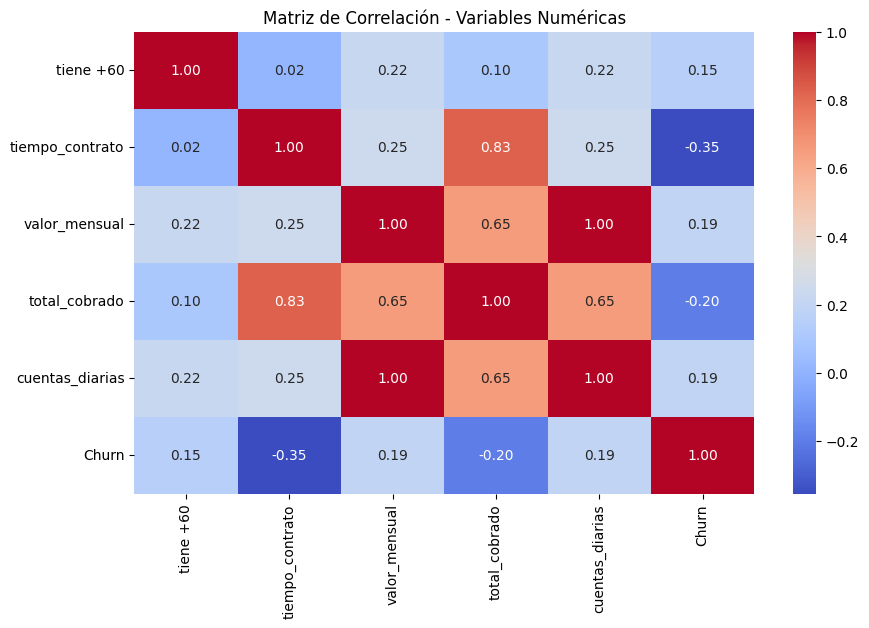

In [9]:
# Selecciono solo las variables numéricas con la funcion .select_dtypes()
df_numericas = df.select_dtypes(include=['int64','float64'])

# Para esto necesito que mi variable de evaluación tambien sea numérica, entonces al nuevo DF que creo le agrego la columna churn con variables binarias mediante el metodo .map()
df_numericas['Churn'] = df['Churn'].map({'Si':1 , 'No':0})

#Luego calculo la matriz de correlación
corr_matrix = df_numericas.corr()

#Visualizo el heatmap de la matriz de correlacion con la biblioteca seaborn
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

In [10]:
df = df.drop(columns=['total_cobrado', 'cuentas_diarias'])

### ✅ Análisis de Churn por categoría (variables categóricas)

Debo analizar las variables categóricas para evaluar la similitud entre ellas y descartar algunas para poder realizar un encode y evaluar la correlación.

- Seleccionar variables categóricas

In [11]:
# Creo un nuevo DF solo con las columnas que tienen variables de tipo objeto
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

- Tabla de proporción por categoría

In [12]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    #Esto crea para cada categoria una tabla de porcentajes de Churn para cada variable
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: genero


Churn,No,Si
genero,,
Femenino,73.040482,26.959518
Masculino,73.795435,26.204565



📌 Analisis de variable: posee_pareja


Churn,No,Si
posee_pareja,,
No,67.023908,32.976092
Si,80.282935,19.717065



📌 Analisis de variable: posee_dependientes


...

Churn,No,Si
tipo_contrato,,
Anual,88.722826,11.277174
Bienal,97.151335,2.848665
Mensual,57.290323,42.709677



📌 Analisis de variable: factura_digital


Churn,No,Si
factura_digital,,
No,83.624302,16.375698
Si,66.410749,33.589251



📌 Analisis de variable: metodo_pago


Churn,No,Si
metodo_pago,,
Cheque electrónico,54.714588,45.285412
Cheque enviado por correo,80.798005,19.201995
Tarjeta de crédito (automático),84.746877,15.253123
Transferencia Bancaria (automática),83.268482,16.731518


### Método Qui-Cuadrado (Chi-Square Test)

En el caso anterior deberia ver columna por columna si tienen una influencia sobre la columna Churn, con este método (Qui-Cuadrado) puedo hacerlo con todas las columnas al mismo tiempo.
Lo que hace el modelo de Qui-Cuadrado es una lista con las variables que tienen mas similitud con la cariable Churn.

In [13]:
from sklearn.preprocessing import LabelEncoder # Para transformar temporariamente las variables categóricas en datos de 0 y 1.
from sklearn.feature_selection import chi2 #

# Creo copia del DF
df_rank = df.copy()

# Convierto el Churn a valores binarios
df_rank['Churn'] = df_rank['Churn'].map({'Si': 1, 'No': 0})

# Separo las variables categóricas
categorical_cols = df_rank.select_dtypes(include=['object']).columns

# Aplico un Label Encoding temporario (Solo para un test estadístico)
le = LabelEncoder()
for col in categorical_cols:
  df_rank[col] = le.fit_transform(df_rank[col])

# Separo X e y Porque quiero hacer la comparacion solo de churn con las demás variables
X_cat = df_rank[categorical_cols]
y = df_rank['Churn']

# Aplico el test de Qui-Cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Creo el DataFrame con el ranking
chi_df = pd.DataFrame({
    'Variable': categorical_cols,
    'Chi2 Score': chi_scores, # Cuanto más alto es el valor del chi2 score mas asociado al churn está la variable
    'p-value': p_values # Es el margen de error, cuanto menor sea mas acertada está la información, Sirve que sea menor que 0.05
})

# Ordeno por importancia
chi_df = chi_df.sort_values(by='Chi2 Score', ascending = False)

chi_df


,Variable,Chi2 Score,p-value
14,metodo_pago,466.119470,2.239792e-103
12,tipo_contrato,392.706273,2.131687e-87
6,seguridad_online,147.165601,7.219883e-34
9,soporte_tecnico,135.439602,2.645952e-31
2,posee_dependientes,131.271509,2.159540e-30
13,factura_digital,104.979224,1.234232e-24
1,posee_pareja,81.857769,1.462409e-19
7,backup_online,31.209832,2.315902e-08
8,proteccion_dispositivo,20.216007,6.917171e-06
10,streaming_tv,17.320615,3.157429e-05


Para obtener una lista con mis variables mas significativas me baso en que el P-values debe ser menor a 0.05.

In [14]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
14,metodo_pago,466.119470,2.239792e-103
12,tipo_contrato,392.706273,2.131687e-87
6,seguridad_online,147.165601,7.219883e-34
9,soporte_tecnico,135.439602,2.645952e-31
2,posee_dependientes,131.271509,2.159540e-30
13,factura_digital,104.979224,1.234232e-24
1,posee_pareja,81.857769,1.462409e-19
7,backup_online,31.209832,2.315902e-08
8,proteccion_dispositivo,20.216007,6.917171e-06
10,streaming_tv,17.320615,3.157429e-05


In [15]:
df = df.drop(columns=['multiples_lineas', 'genero', 'servicio_telefono'])

# 🎯 Split (Divido los datos)

Antes de hacer la separacion entre train y test debo separar la variable de respuesta de las variables explicativas.

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Split N°2

Ahora separo entre train y test para que el modelo no se acostumbre a los datos y luego de entrenarlo pueda obtener la variable de respuesta con el modelo utilizando las variables de test y comparar con las variables de respuesta-test que ya tengo. Así evalúo que tan preciso es mi modelo.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # Tamaño de la muestra que se va a utilizar para test
                                                    stratify=y, # Para balancear la division de valores de acuerdo con el porcentaje de churn
                                                    random_state=42) # Semilla para poder reproducir siempre la misma división

# One-Hot Encoding

Como las variables aún son de tipo categóricas debo realizar algun encoding para que puedan ser utilizadas para entrenar un modelo

In [18]:
# Aplico One-Hot Encoding en el conjunto de entrenamiento
X_train = pd.get_dummies(X_train, drop_first=True) # El drop_first= True elimina la primera columna para evitar multicolinealidad

# Aplico One-Hot Encoding en el conjunto de prueba
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantizo que los conjuntos de entrenamiento y prueba tengan las mismas columnas, la funcion align me lo garantiza porque a veces X_test puede no tener algunas variables categóricas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1416 to 1465
Data columns (total 19 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   tiene +60                                        5625 non-null   int64  
 1   tiempo_contrato                                  5625 non-null   int64  
 2   valor_mensual                                    5625 non-null   float64
 3   posee_pareja_Si                                  5625 non-null   bool   
 4   posee_dependientes_Si                            5625 non-null   bool   
 5   tipo_internet_Fibra óptica                       5625 non-null   bool   
 6   tipo_internet_No                                 5625 non-null   bool   
 7   seguridad_online_Si                              5625 non-null   bool   
 8   backup_online_Si                                 5625 non-null   bool   
 9   proteccion_dispositivo_Si       

In [20]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 984 to 2092
Data columns (total 19 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   tiene +60                                        1407 non-null   int64  
 1   tiempo_contrato                                  1407 non-null   int64  
 2   valor_mensual                                    1407 non-null   float64
 3   posee_pareja_Si                                  1407 non-null   bool   
 4   posee_dependientes_Si                            1407 non-null   bool   
 5   tipo_internet_Fibra óptica                       1407 non-null   bool   
 6   tipo_internet_No                                 1407 non-null   bool   
 7   seguridad_online_Si                              1407 non-null   bool   
 8   backup_online_Si                                 1407 non-null   bool   
 9   proteccion_dispositivo_Si        

## Verifico desbalanceamiento de mi variable respuesta

El desbalanceamiento es, en este caso, la proporcion de Churn entre si y no.

In [21]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.422222
Si,26.577778


Cuando entreno el modelo, las metricas me muestran que tan bien entrenado está. Entre ellas esta la accuracy, que si es muy alta nos dice que el modelo está bien entrenado. Pero si el conjunto de datos está desbalanceado entonces la accuracy nos puede dar valores altos pero no podemos confiar tanto en ella porque puede ser erronea dado el desbalanceamiento.
La accuracy es el porcentaje en el que el modelo acerto los datos predichos respecto a los datos de prueba.

# 🦾 Entrenamiento

## Modelo 1 - Regresión Logística

In [22]:
from sklearn.linear_model import LogisticRegression # Importamos el modelo
from sklearn.metrics import classification_report # Importamos las métricas que queremos evaluar

log_model = LogisticRegression(max_iter=1000) # Inicializo el modelo con un máximo de iteraciones para el entrenamiento.
log_model.fit(X_train, y_train) # Entreno el modelo

y_pred_log_normal = log_model.predict(X_test) # Obtengo la variable respuesta con el modelo a partir de los datos de prueba

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
          Si       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



El Recall es el dato que me dice que porcentaje de los datos de precision son realmente un dato verdadero, es decir en este caso si predijo el 83% de los no, el recall nos dice que el 90% de esas predicciones es correcta. Es decir el recall nos da la confianza sobre la predicción.

## Modelo 2 - Random Forest (Más robusto)

In [23]:
from sklearn.ensemble import RandomForestClassifier # Importo el modelo, no es un modelo lineal

rf_model = RandomForestClassifier(random_state=42) # Inicializo el modelo con una semilla de 42
rf_model.fit(X_train, y_train) # Entreno el modelo con las variables de entrenamiento

y_pred_rf = rf_model.predict(X_test) # Obtengo la variable respuesta con el modelo a partir de los datos de prueba

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
          Si       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Regresión Logística con balanceo

In [24]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced") # Aqui con la propiedad class_weight = 'balanced' balanceo el conjunto de datos
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1033
          Si       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



El balanceo es como si fuera una máscara, no modifica realmente el conjunto de datos. Lo que sucede en este caso es que se pondera como mas importante a la variable que se encuentra con menos proporción.

# Evaluación

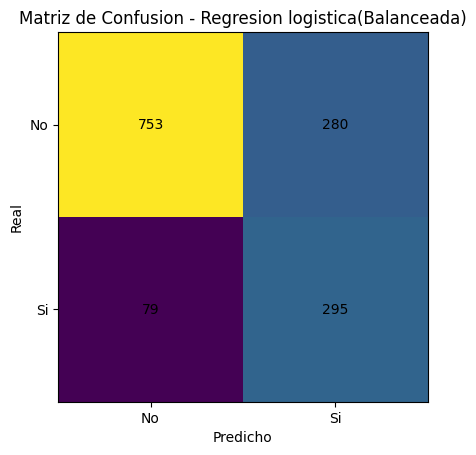

In [25]:
from sklearn.metrics import confusion_matrix # Importo la matriz de confusión
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica(Balanceada)")
plt.xlabel("Predicho")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Si"])
plt.yticks([0,1], ["No", "Si"])

plt.show()

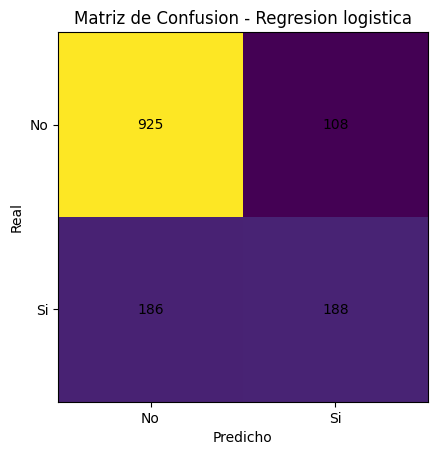

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica")
plt.xlabel("Predicho")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Si"])
plt.yticks([0,1], ["No", "Si"])

plt.show()

#📄Informe final

**Introduccción**

La empresa Telecom X, nos ha contratado como científico de datos, en específico para el proyecto "Churn de Clientes". Este proyecto tiene como objetivo analizar un problema que enfrenta la empresa el cual trata sobre la alta tasa de cancelaciones que tienen de los clientes, para lo cual, Telecom X quiere que se analicen los datos que tienen de sus clientes y se desarrolle un modelo predictivo que pueda indentificar que clientes van a cancelar su servicio con un alto porcentaje de confianza.

Los datos se obtuvieron a partir de un trabajo anterior en el cual se les realizo una limpieza y tratamiento.

Luego con la base de datos se realizó un preprocesamiento para eliminar las columnas irrelevantes. Tambien se realizó un análisis exploratorio para preveer qué variables numéricas tenian correlación, con el objetivo de evitar la multilinealidad. Continuando con el análisis, se evaluó cuanto afectaban las variables categoricas, analizando la similitud entre ellas y descartando algunas para poder realizar un encode y evaluar la correlación.

Teniendo todas la variables a utilizar se realizo la division de los datos para prueba y entrenmiento. Prosiguiendo con un encoding aplicando One-Hot Encoding y por ultimo se realizo una prueba de desbalanceamiento.

Asi con los datos desbalanceados se entrenaron dos modelos, el modelo de Regresión Logística y el modelo Random Forest, las metricas resultaron como siguen:

Regresion logistica

                    precision    recall  f1-score   support

              No       0.83      0.90      0.86      1033
              Si       0.64      0.50      0.56       374

        accuracy                           0.79      1407
       macro avg       0.73      0.70      0.71      1407
    weighted avg       0.78      0.79      0.78      1407

Random Forest

                    precision    recall  f1-score   support

              No       0.83      0.89      0.86      1033
              Si       0.63      0.49      0.55       374

        accuracy                           0.79      1407
       macro avg       0.73      0.69      0.71      1407
    weighted avg       0.78      0.79      0.78      1407


Vemos que si bien la accuracy (Exactitud) es alta, El recall, es decir el porcentaje de veracidad de los datos predichos es bajo para el "Si" es decir que ambos modelos no estan realizando buenas predicciones de los clientes que si se van a dar de baja.

Para mejorar estas métricas lo que hacemos es aplicarle un balanceo al metodo de Regresión Logística y las métricas resultantes son las siguientes:

Regresion logistica

                    precision    recall  f1-score   support

              No       0.91      0.73      0.81      1033
              Si       0.51      0.79      0.62       374

        accuracy                           0.74      1407
       macro avg       0.71      0.76      0.71      1407
    weighted avg       0.80      0.74      0.76      1407

Como vemos la accuracy disminuyó un poco pero aumento a 80% el recall es decir que el modelo predice un 80% de los clientes que si se van a dar de baja.

Podemos ver a continuacion la comparacion de las matrices de confusion del modelo de Regresión Logística con los datos balanceados y desbalanceados:

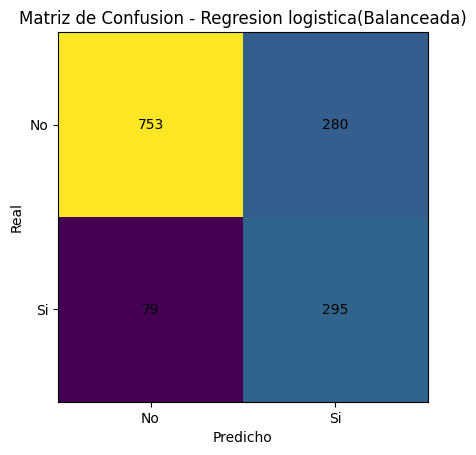

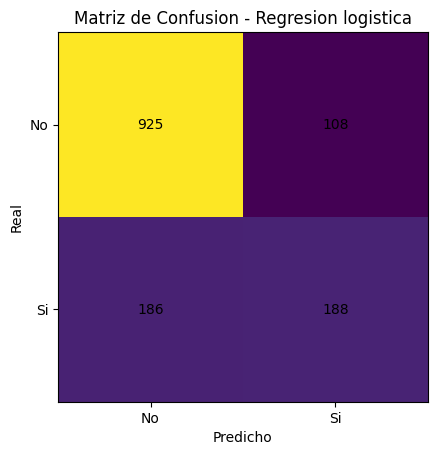

Vemos que con los datos desbalanceados, hay una gran cantidad de clientes que dan de baja su servicio y no estan siendo correctamente predecidos por el modelo. Por su parte cuando el modelo tiene datos balanceados predice una gran parte de los clientes que se dan de baja.

Teniendo en cuenta lo que nos solicita Telecom X, que es predecir la mayor cantidad de clientes que se van a dar de baja con alta efectividad, se concluye que el modelo entrenado es muy aceptable y util para lo que se solicitó.